In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
# ploting probablity density function for both 

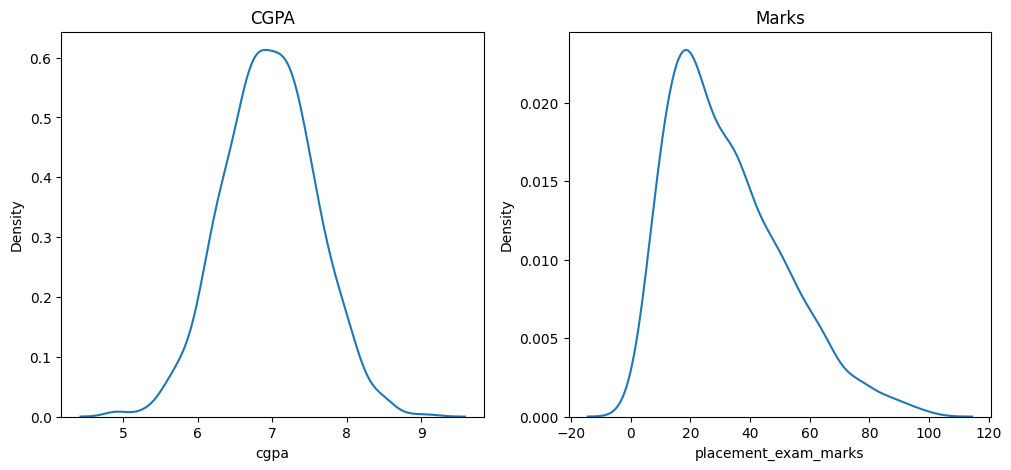

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.kdeplot(df['cgpa'])
plt.title('CGPA')

plt.subplot(1,2,2)
sns.kdeplot(df['placement_exam_marks'])
plt.title('Marks')
plt.show()

In [7]:
# we can see cgpa is normal but placement marks is not that normal 
df.describe()['cgpa']

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

In [10]:
# keeping the higher and lower bounds 
print(df['cgpa'].mean()+df['cgpa'].std()*3)
print(df['cgpa'].mean()-df['cgpa'].std()*3)

8.808933625397168
5.113546374602832


In [23]:
# we can see we got the upper and lower bounds now we can see hou many outliers we have 
df[(df['cgpa']<5.1135) | (df['cgpa']>8.808933)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [22]:
# we have 5 outliers

# Trimming 

In [25]:
# just use the condition 
new_df_trimmed = df[(df['cgpa']>5.1135) & (df['cgpa']<8.808933)]

In [27]:
new_df_trimmed.shape

(995, 3)

In [28]:
# we can use the z score method also 
df['zscore'] = (df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [30]:
df[(df['zscore']<-3)|(df['zscore']>3)]

,cgpa,placement_exam_marks,placed,zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [31]:
# now we can drop these rows and get our new collumn 

# Capping 

In [32]:
ul = df['cgpa'].mean()+df['cgpa'].std()*3
ll = df['cgpa'].mean()-df['cgpa'].std()*3

In [40]:
df['cgpa'] = np.where(df['cgpa']<ll,ll,np.where(df['cgpa']>ul,ul,df['cgpa']))

In [44]:
df.describe ()

,cgpa,placement_exam_marks,placed,zscore
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,6.961499,32.225000,0.489000,-1.465494e-16
std,0.612688,19.130822,0.500129,1.000000e+00
min,5.113546,0.000000,0.000000,-3.362960e+00
25%,6.550000,17.000000,0.000000,-6.677081e-01
50%,6.960000,28.000000,0.000000,-2.013321e-03
75%,7.370000,44.000000,1.000000,6.636815e-01
max,8.808934,100.000000,1.000000,3.505062e+00


In [ ]:
# done 